In [34]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.metrics import log_loss, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
train_df = pd.read_csv('data/base/train.csv')
val_df = pd.read_csv('data/base/val.csv')
test_df = pd.read_csv('data/base/test.csv')

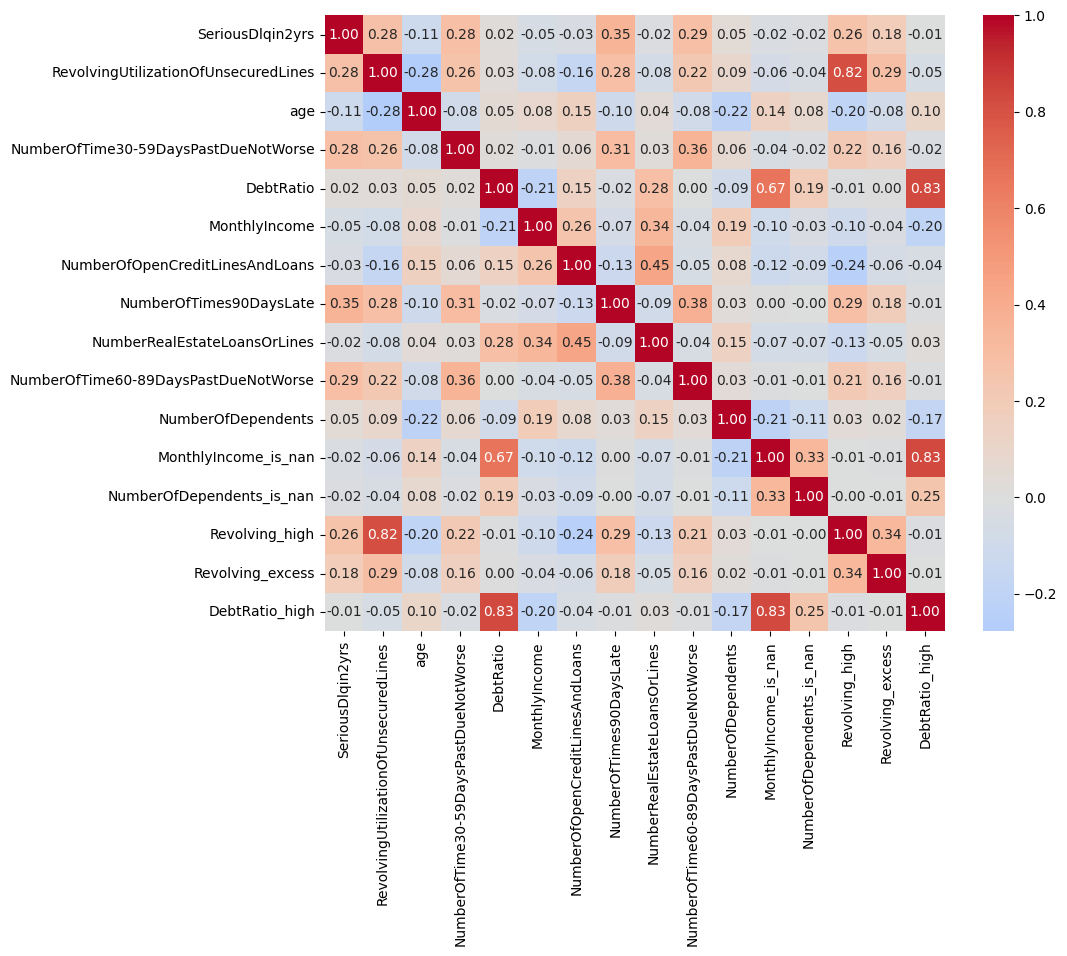

In [3]:
corr = train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.show()

In [4]:
main_cols = ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 
             'NumberOfTime30-59DaysPastDueNotWorse', 'MonthlyIncome',
             'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
             'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 
             'NumberOfDependents', 'MonthlyIncome_is_nan', 
             'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess', 
             'DebtRatio_high'
             ]

train_df[main_cols].to_csv('data/base_fs/train.csv', index=False)
val_df[main_cols].to_csv('data/base_fs/val.csv', index=False)
test_df[main_cols].to_csv('data/base_fs/test.csv', index=False)

In [5]:
fe_train_df = train_df.copy()
fe_val_df = val_df.copy()
fe_test_df = test_df.copy()

def processing_fe(df):
    df = df.copy()

    df['Late_severity_log'] = np.log1p(
        df['NumberOfTimes90DaysLate'] * 2 +
        df['NumberOfTime60-89DaysPastDueNotWorse'] * 1.5 +
        df['NumberOfTime30-59DaysPastDueNotWorse']
    )
    df = df.drop([
        'NumberOfTime30-59DaysPastDueNotWorse',
        'NumberOfTime60-89DaysPastDueNotWorse',
    ], axis=1)

    return df

fe_train_df = processing_fe(train_df)
fe_val_df = processing_fe(val_df)
fe_test_df = processing_fe(test_df)

In [6]:
fe_train_df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfDependents,MonthlyIncome_is_nan,NumberOfDependents_is_nan,Revolving_high,Revolving_excess,DebtRatio_high,Late_severity_log
0,0,0.000000,49,0.127227,5163.0,5,0,0,0,0,0,0,0,0,0.0
1,0,0.033105,37,0.423063,2800.0,4,0,1,1,0,0,0,0,0,0.0
2,0,0.007948,39,0.685663,3333.0,11,0,1,0,0,0,0,0,0,0.0
3,0,0.576297,57,0.320077,15161.0,14,0,4,0,0,0,0,0,0,0.0
4,0,0.623724,35,0.534226,6500.0,9,0,3,1,0,0,0,0,0,0.0


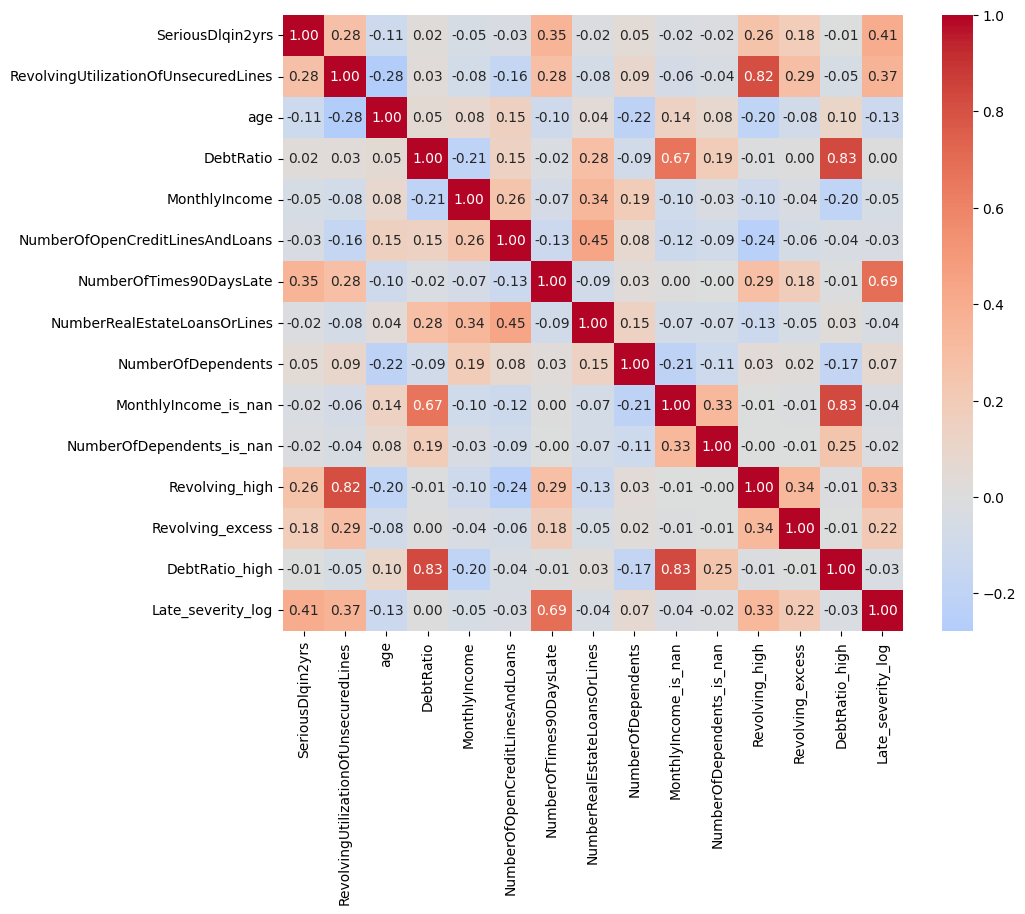

In [7]:
corr = fe_train_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.show()

In [8]:
fe_train_df.to_csv('data/fe/train.csv', index=False)
fe_val_df.to_csv('data/fe/val.csv', index=False)
fe_test_df.to_csv('data/fe/test.csv', index=False)

In [9]:
main_cols = ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfOpenCreditLinesAndLoans', 
            'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'MonthlyIncome_is_nan', 
             'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess', 'DebtRatio_high', 'Late_severity_log']

fe_train_df[main_cols].to_csv('data/fe_fs/train.csv', index=False)
fe_val_df[main_cols].to_csv('data/fe_fs/val.csv', index=False)
fe_test_df[main_cols].to_csv('data/fe_fs/test.csv', index=False)

In [10]:
fe2_train_df = fe_train_df.copy()
fe2_val_df = fe_val_df.copy()
fe2_test_df = fe_test_df.copy()

def processing_fe2(df): 
    df = df.copy()

    df['Late_per_credit'] = (
        df['Late_severity_log'] /
        (df['NumberOfOpenCreditLinesAndLoans'] + 1e-5)
    )

    df['Is_old'] = (df['age'] > 55).astype(int)
    
    return df 

fe2_train_df = processing_fe2(fe2_train_df)
fe2_val_df = processing_fe2(fe2_val_df)
fe2_test_df = processing_fe2(fe2_test_df)

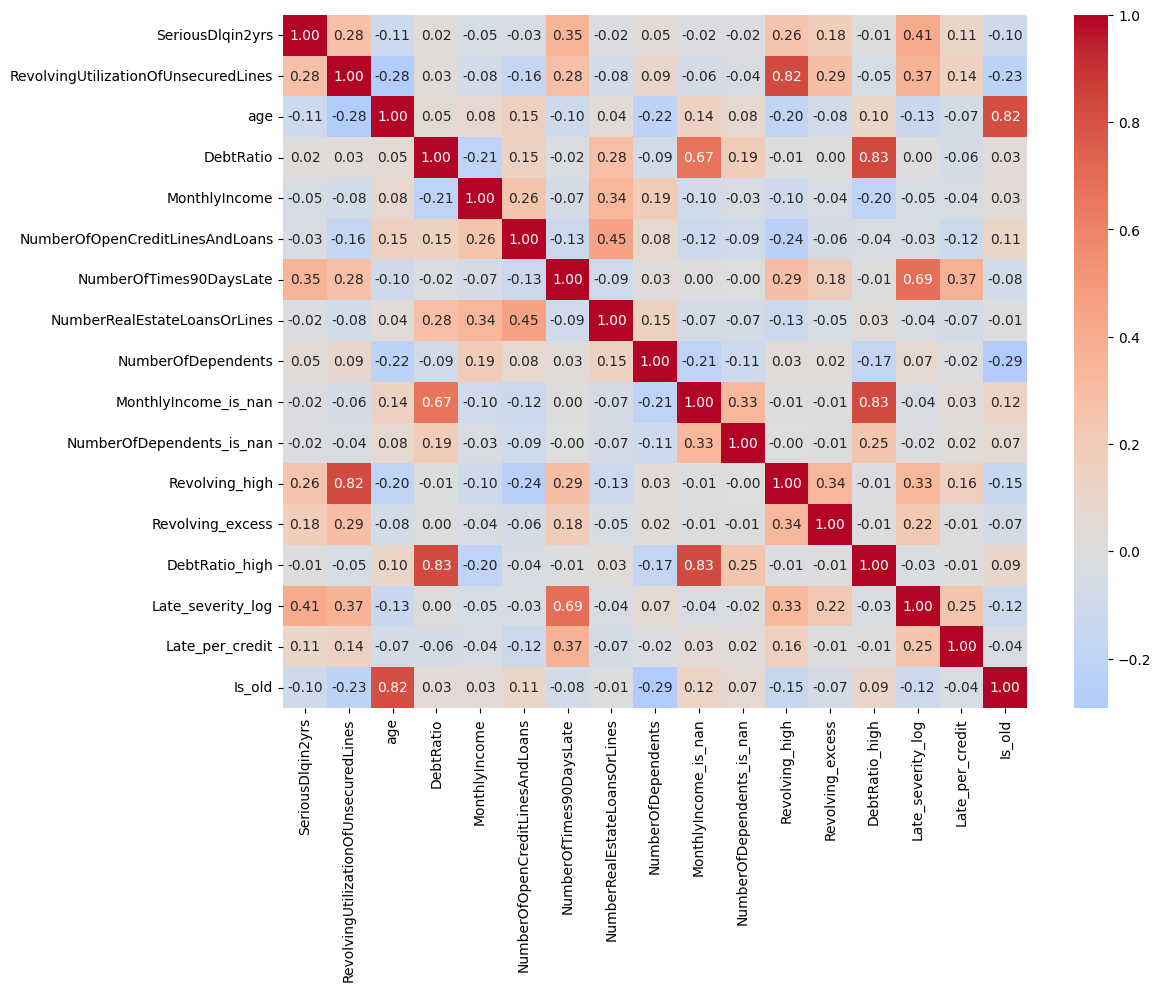

In [11]:
corr = fe2_train_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f')
plt.show()

In [13]:
fe2_train_df.to_csv('data/fe2/train.csv', index=False)
fe2_val_df.to_csv('data/fe2/val.csv', index=False)
fe2_test_df.to_csv('data/fe2/test.csv', index=False)

In [15]:
main_cols = ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
             'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 
             'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 
             'NumberOfDependents', 'MonthlyIncome_is_nan', 
             'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess', 
             'DebtRatio_high', 'Late_severity_log', 'Late_per_credit', 'Is_old'
]

fe2_train_df[main_cols].to_csv('data/fe2_fs/train.csv', index=False)
fe2_val_df[main_cols].to_csv('data/fe2_fs/val.csv', index=False)
fe2_test_df[main_cols].to_csv('data/fe2_fs/test.csv', index=False)

### Тест данных и моделей

In [2]:
train_df = pd.read_csv('data/base/train.csv')
val_df = pd.read_csv('data/base/val.csv')
test_df = pd.read_csv('data/base/test.csv')

fs_train_df = pd.read_csv('data/base_fs/train.csv')
fs_val_df = pd.read_csv('data/base_fs/val.csv')
fs_test_df = pd.read_csv('data/base_fs/test.csv')

fe_train_df = pd.read_csv('data/fe/train.csv')
fe_val_df = pd.read_csv('data/fe/val.csv')
fe_test_df = pd.read_csv('data/fe/test.csv')

fe_fs_train_df = pd.read_csv('data/fe_fs/train.csv')
fe_fs_val_df = pd.read_csv('data/fe_fs/val.csv')
fe_fs_test_df = pd.read_csv('data/fe_fs/test.csv')

fe2_train_df = pd.read_csv('data/fe2/train.csv')
fe2_val_df = pd.read_csv('data/fe2/val.csv')
fe2_test_df = pd.read_csv('data/fe2/test.csv')

fe2_fs_train_df = pd.read_csv('data/fe2_fs/train.csv')
fe2_fs_val_df = pd.read_csv('data/fe2_fs/val.csv')
fe2_fs_test_df = pd.read_csv('data/fe2_fs/test.csv')

In [3]:
def plot_feature(df, col):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    
    sns.violinplot(x=df[col], orient='h', ax=axes[0])
    axes[0].set_title(f'{col}')
    
    sns.kdeplot(
        data=df,
        x=col,
        hue='SeriousDlqin2yrs',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[1]
    )
    axes[1].set_title(f'{col} vs target')
    
    plt.tight_layout()
    plt.show()

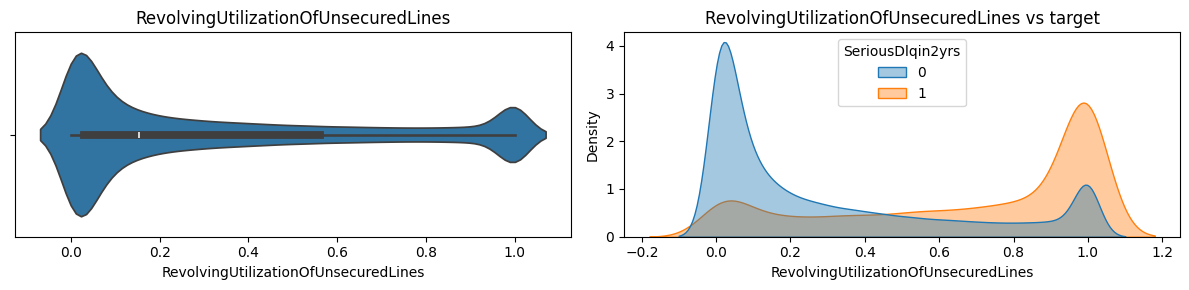

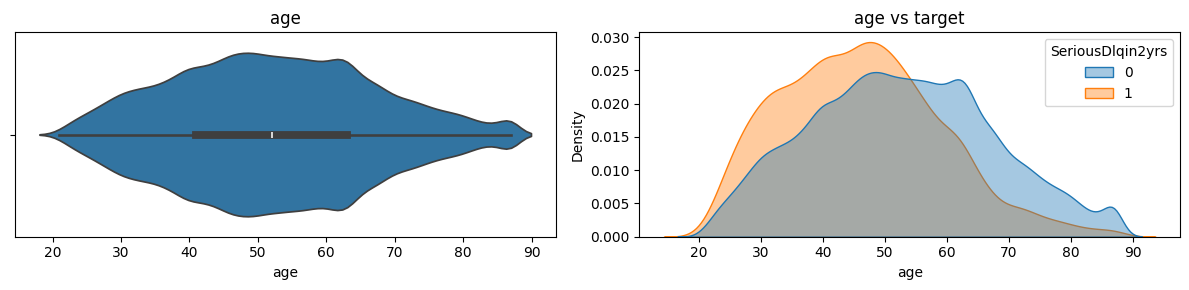

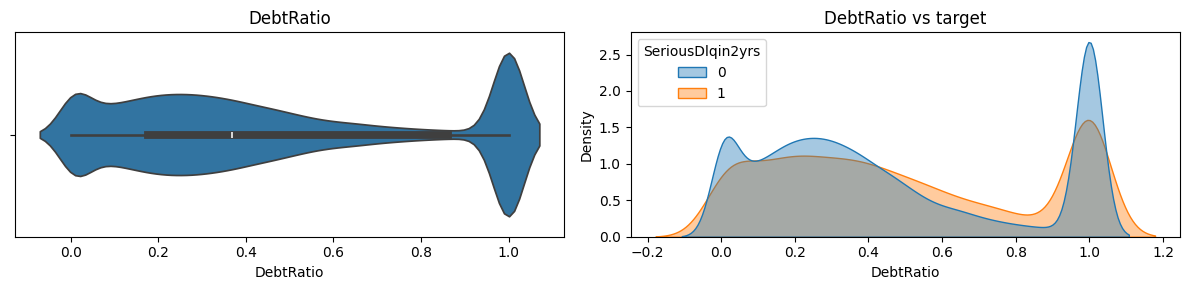

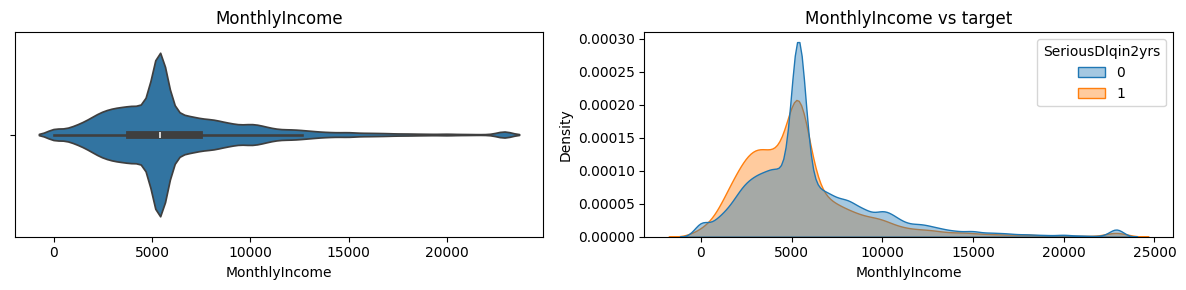

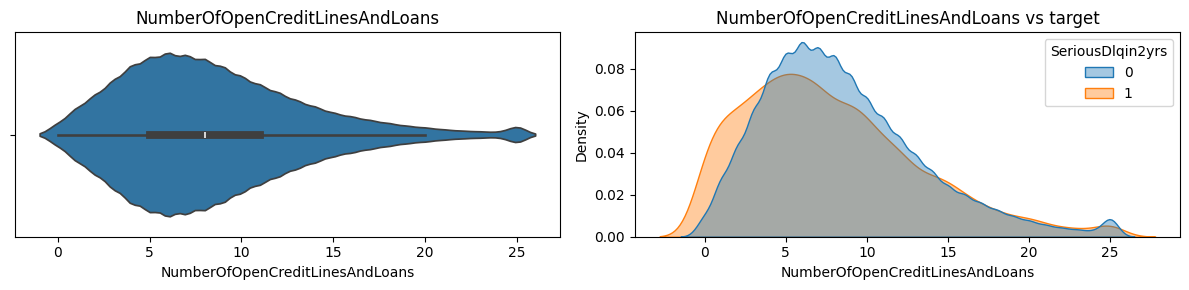

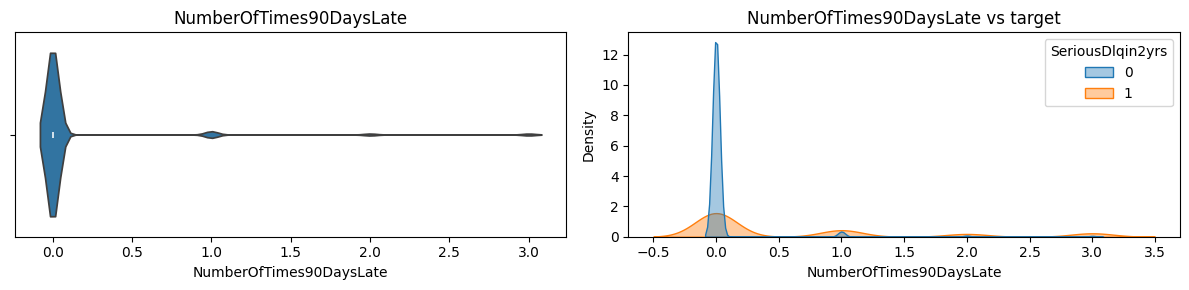

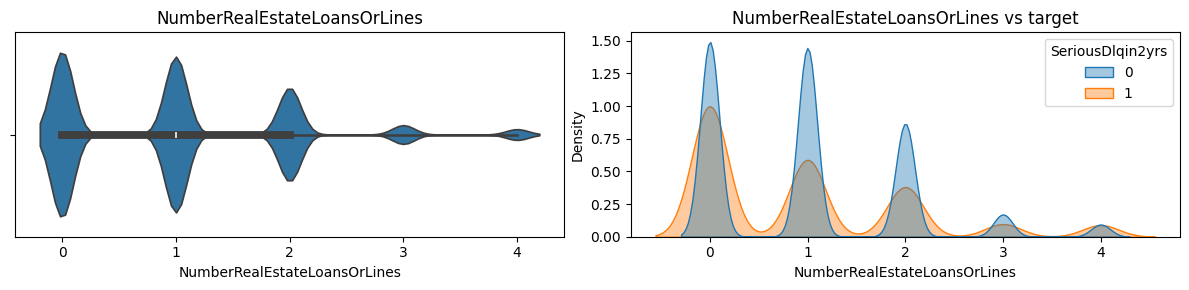

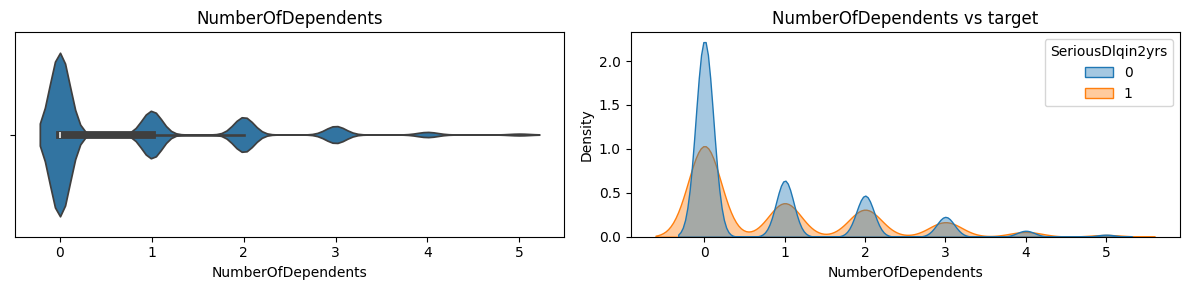

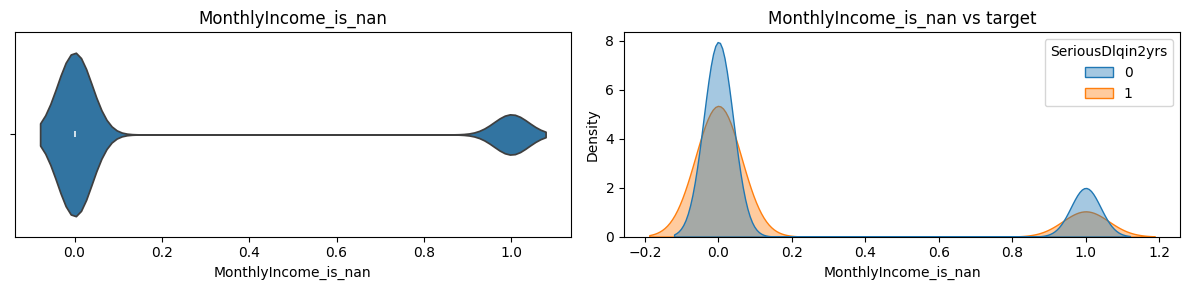

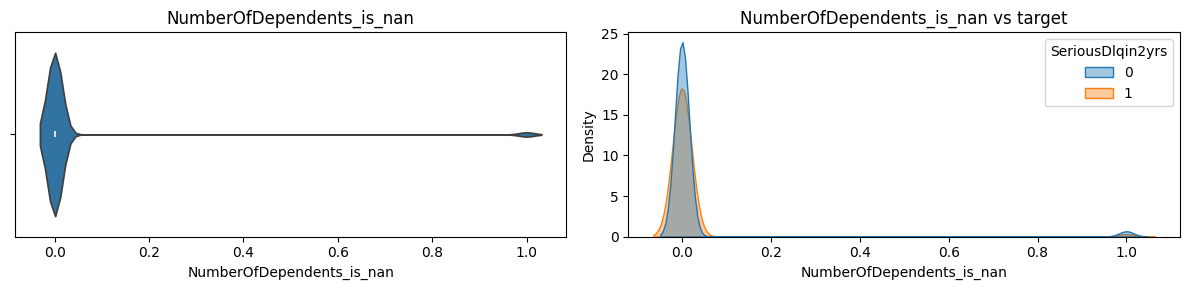

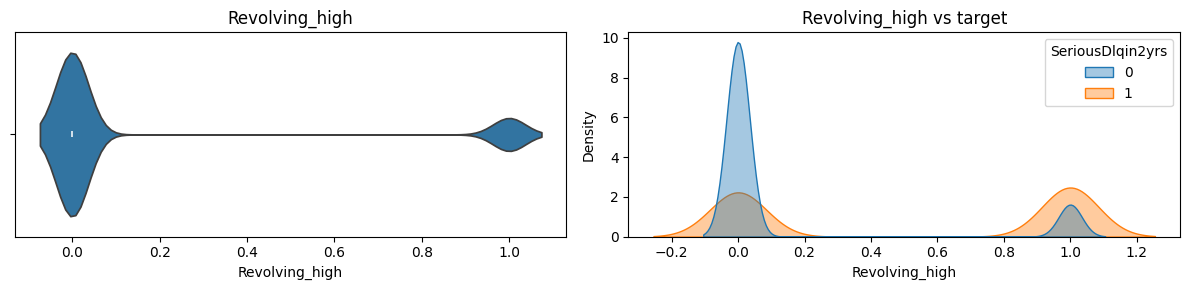

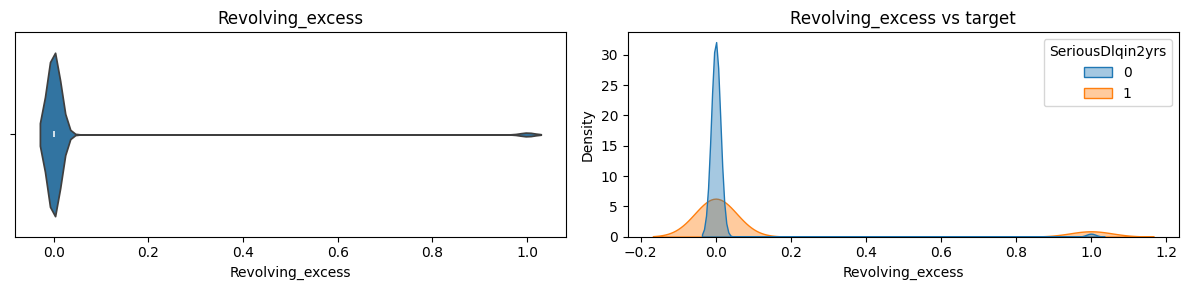

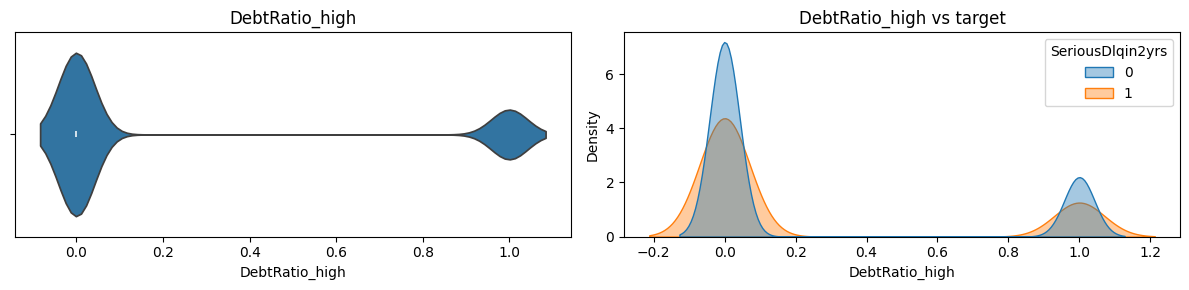

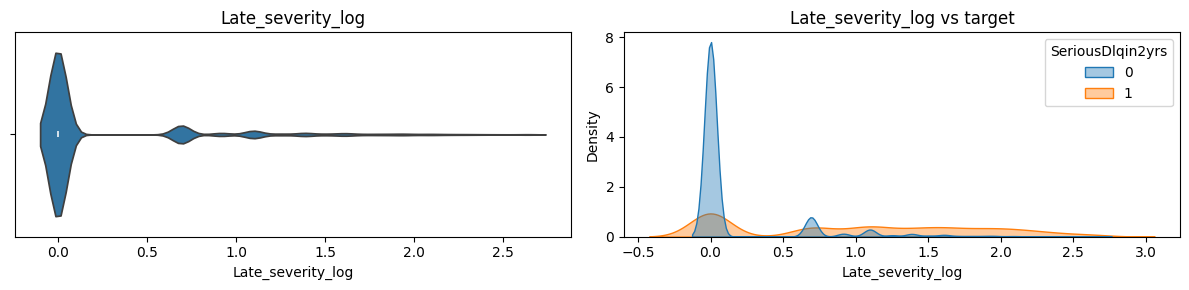

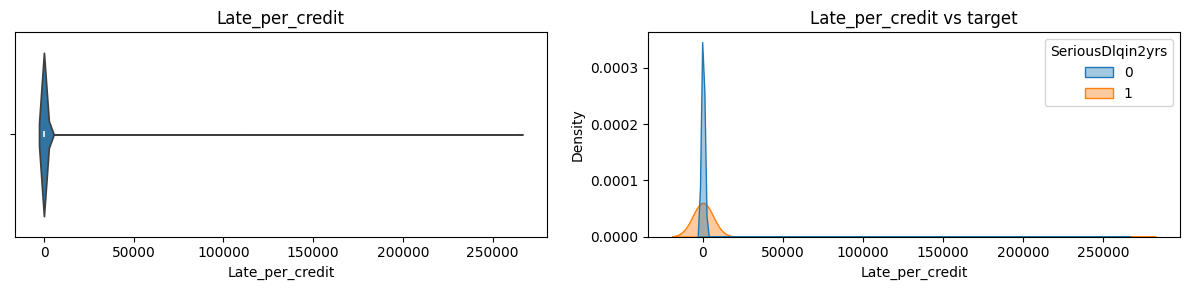

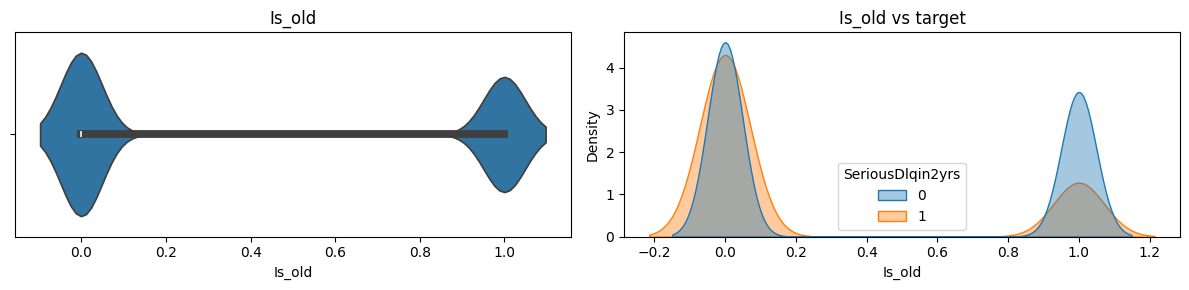

In [4]:
cols = ['RevolvingUtilizationOfUnsecuredLines', 'age',
       'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans',
       'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines',
       'NumberOfDependents', 'MonthlyIncome_is_nan',
       'NumberOfDependents_is_nan', 'Revolving_high', 'Revolving_excess',
       'DebtRatio_high', 'Late_severity_log', 'Late_per_credit', 'Is_old']

for col in cols:
    plot_feature(fe2_train_df, col)

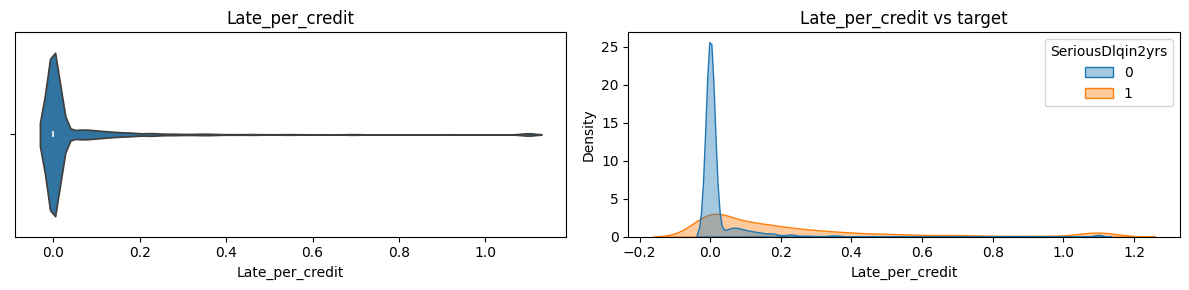

In [5]:
col = 'Late_per_credit'
buf_df = fe2_train_df.copy()

high = buf_df[col].quantile(0.99)
buf_df[col] = buf_df[col].clip(upper=high)

plot_feature(buf_df, col)

In [6]:
fe2_train_df = buf_df.copy()

In [7]:
col = 'Late_per_credit'
buf_df = fe2_fs_train_df.copy()

high = buf_df[col].quantile(0.99)
buf_df[col] = buf_df[col].clip(upper=high)

In [8]:
fe2_fs_train_df = buf_df.copy()

In [9]:
def split_xy(df, target_col='SeriousDlqin2yrs'):
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return X, y

X_train, y_train = split_xy(train_df)
X_val, y_val = split_xy(val_df)
X_test, y_test = split_xy(test_df)

X_fs_train, y_fs_train = split_xy(fs_train_df)
X_fs_val, y_fs_val = split_xy(fs_val_df)
X_fs_test, y_fs_test = split_xy(fs_test_df)

X_fe_train, y_fe_train = split_xy(fe_train_df)
X_fe_val, y_fe_val = split_xy(fe_val_df)
X_fe_test, y_fe_test = split_xy(fe_test_df)

X_fe_fs_train, y_fe_fs_train = split_xy(fe_fs_train_df)
X_fe_fs_val, y_fe_fs_val = split_xy(fe_fs_val_df)
X_fe_fs_test, y_fe_fs_test = split_xy(fe_fs_test_df)

X_fe2_train, y_fe2_train = split_xy(fe2_train_df)
X_fe2_val, y_fe2_val = split_xy(fe2_val_df)
X_fe2_test, y_fe2_test = split_xy(fe2_test_df)

X_fe2_fs_train, y_fe2_fs_train = split_xy(fe2_fs_train_df)
X_fe2_fs_val, y_fe2_fs_val = split_xy(fe2_fs_val_df)
X_fe2_fs_test, y_fe2_fs_test = split_xy(fe2_fs_test_df)

In [10]:
datasets = {
    'base': [
        [X_train, y_train],
        [X_val, y_val],
        [X_test, y_test]
    ],
    'base_fs': [
        [X_fs_train, y_fs_train], 
        [X_fs_val, y_fs_val],
        [X_fs_test, y_fs_test]
    ],
    'fe': [
        [X_fe_train, y_fe_train], 
        [X_fe_val, y_fe_val], 
        [X_fe_test, y_fe_test]
    ], 
    'fe_fs': [
        [X_fe_fs_train, y_fe_fs_train], 
        [X_fe_fs_val, y_fe_fs_val], 
        [X_fe_fs_test, y_fe_fs_test]
    ],
    'fe2': [
        [X_fe2_train, y_fe2_train], 
        [X_fe2_val, y_fe2_val], 
        [X_fe2_test, y_fe2_test]
    ],
    'fe2_fs': [
        [X_fe2_fs_train, y_fe2_fs_train], 
        [X_fe2_fs_val, y_fe2_fs_val], 
        [X_fe2_fs_test, y_fe2_fs_test]
    ]
}

In [11]:
def wrap_model(
    model,
    log_features=[],
    scale_features=[]
):
    def preprocess(X):
        X = X.copy()

        for col in log_features:
            if col in X.columns:
                X[col] = np.log1p(X[col])
        
        existing_scale_cols = [col for col in scale_features if col in X.columns]
        if existing_scale_cols:
            scaler = StandardScaler()
            X[existing_scale_cols] = scaler.fit_transform(X[existing_scale_cols])

        return X

    pipe = Pipeline([
        ('preprocess', FunctionTransformer(preprocess)),
        ('model', model)
    ])

    pipe.set_output(transform='pandas')
    return pipe

In [12]:
models = {
    
    'LogReg': wrap_model(
        model=LogisticRegression(),
        log_features=[
            'RevolvingUtilizationOfUnsecuredLines',
            'MonthlyIncome'
        ], 
        scale_features=[
            'RevolvingUtilizationOfUnsecuredLines', 
            'age', 
            'DebtRatio', 
            'NumberRealEstateLoansOrLines'
        ]
    ), 

    'RandomForest': wrap_model(
        model=RandomForestClassifier(), 
        log_features=[
            'MonthlyIncome'
        ], 
        scale_features=[]
    ), 

    'GBM': wrap_model(
        model=GradientBoostingClassifier(), 
        log_features=[
            'MonthlyIncome'
        ], 
        scale_features=[]
    ), 

    'XGB': wrap_model(
        model=XGBClassifier(eval_metric='logloss'), 
        log_features=[
            'MonthlyIncome'
        ], 
        scale_features=[]
    ), 

    'LGBM': wrap_model(
        model=LGBMClassifier(), 
        log_features=[
            'MonthlyIncome'
        ], 
        scale_features=[]
    ), 

    'CatBoost': wrap_model(
        model=CatBoostClassifier(verbose=0), 
        log_features=[
            'MonthlyIncome'
        ], 
        scale_features=[]
    ), 
    
}

In [13]:
def evaluate_model(
    model, 
    X, y, 
    dataset_name, model_name,
    threshold=0.5
):
    probs = model.predict_proba(X)[:, 1]
    
    preds = (probs >= threshold).astype(int)

    metrics = {
        'dataset': dataset_name, 
        'model': model_name,
        'BCE': log_loss(y, probs),
        'AUC': roc_auc_score(y, probs),
        'Accuracy': accuracy_score(y, preds),
        'Precision': precision_score(y, preds, zero_division=0),
        'Recall': recall_score(y, preds, zero_division=0),
        'F1': f1_score(y, preds, zero_division=0),
    }

    return metrics

In [14]:
results = []

for model_name in models:
    print(f"Model: {model_name}")
    for dataset_name in datasets: 
        print(f"  Dataset: {dataset_name}")
        X_train, y_train = datasets[dataset_name][0]
        X_test, y_test = datasets[dataset_name][2]
        
        models[model_name].fit(
            X_train, y_train
        )
        
        metrics = evaluate_model(
            models[model_name], 
            X_test, y_test, 
            dataset_name, model_name
        )
        results.append(metrics)
            
results_df = pd.DataFrame(results)

Model: LogReg
  Dataset: base
  Dataset: base_fs
  Dataset: fe
  Dataset: fe_fs
  Dataset: fe2
  Dataset: fe2_fs
Model: RandomForest
  Dataset: base
  Dataset: base_fs
  Dataset: fe
  Dataset: fe_fs
  Dataset: fe2
  Dataset: fe2_fs
Model: GBM
  Dataset: base
  Dataset: base_fs
  Dataset: fe
  Dataset: fe_fs
  Dataset: fe2
  Dataset: fe2_fs
Model: XGB
  Dataset: base
  Dataset: base_fs
  Dataset: fe
  Dataset: fe_fs
  Dataset: fe2
  Dataset: fe2_fs
Model: LGBM
  Dataset: base
[LightGBM] [Info] Number of positive: 7018, number of negative: 97982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002656 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066838 -> initscore=-2.636306
[LightGBM] [Info]

In [23]:
results_df.sort_values("AUC", ascending=False).head()

,dataset,model,BCE,AUC,Accuracy,Precision,Recall,F1
14,fe,GBM,0.178398,0.862209,0.937644,0.600398,0.200798,0.300947
12,base,GBM,0.178667,0.862086,0.937422,0.599174,0.192819,0.291751
16,fe2,GBM,0.178689,0.861687,0.936889,0.582677,0.196809,0.294235
28,fe2,LGBM,0.178812,0.861188,0.936800,0.587234,0.183511,0.279635
26,fe,LGBM,0.178657,0.860895,0.937156,0.595745,0.186170,0.283688


In [24]:
results_df.sort_values("BCE", ascending=False).head()

,dataset,model,BCE,AUC,Accuracy,Precision,Recall,F1
9,fe_fs,RandomForest,0.402941,0.816910,0.932000,0.479814,0.205452,0.287709
11,fe2_fs,RandomForest,0.331829,0.827531,0.934844,0.532423,0.207447,0.298565
7,base_fs,RandomForest,0.315905,0.830311,0.934267,0.524752,0.176197,0.263813
10,fe2,RandomForest,0.312655,0.833453,0.934711,0.531532,0.196144,0.286547
6,base,RandomForest,0.308080,0.832850,0.935067,0.542074,0.184176,0.274938


In [25]:
results_df.sort_values("F1", ascending=False).head()

,dataset,model,BCE,AUC,Accuracy,Precision,Recall,F1
5,fe2_fs,LogReg,0.292930,0.856060,0.936711,0.567568,0.223404,0.320611
4,fe2,LogReg,0.292879,0.856044,0.936044,0.555556,0.216090,0.311154
3,fe_fs,LogReg,0.187734,0.856945,0.938044,0.608696,0.204787,0.306468
22,fe2,XGB,0.186402,0.849107,0.935467,0.544218,0.212766,0.305927
20,fe,XGB,0.185701,0.849394,0.936444,0.567273,0.207447,0.303797


In [26]:
results_df.sort_values("Recall", ascending=False).head()

,dataset,model,BCE,AUC,Accuracy,Precision,Recall,F1
5,fe2_fs,LogReg,0.292930,0.856060,0.936711,0.567568,0.223404,0.320611
4,fe2,LogReg,0.292879,0.856044,0.936044,0.555556,0.216090,0.311154
22,fe2,XGB,0.186402,0.849107,0.935467,0.544218,0.212766,0.305927
11,fe2_fs,RandomForest,0.331829,0.827531,0.934844,0.532423,0.207447,0.298565
20,fe,XGB,0.185701,0.849394,0.936444,0.567273,0.207447,0.303797


Топ комбинаций:
- fe + GBM
- fe2_fs + LogReg
- fe + LGBM

### Доработка данных

In [35]:
fe = datasets['fe']
fe2_fs = datasets['fe2_fs']

GBM = models['GBM']
LogReg = models['LogReg']
LGBM = models['LGBM']

In [41]:
def feature_importance(model, data):
    model.fit(data[0][0], data[0][1])
    result = permutation_importance(
        model,
        data[1][0], data[1][1],
        n_repeats=5, 
        random_state=42, 
        scoring='roc_auc'
    )
    importance = pd.DataFrame({
        'feature': data[1][0].columns,
        'importance': result.importances_mean
    }).sort_values('importance', ascending=False)
    
    return importance

In [55]:
result = feature_importance(GBM, fe)

result[result['importance'] >= 0.001]

,feature,importance
13,Late_severity_log,0.106779
0,RevolvingUtilizationOfUnsecuredLines,0.064474
1,age,0.009668
4,NumberOfOpenCreditLinesAndLoans,0.005253
6,NumberRealEstateLoansOrLines,0.003791
2,DebtRatio,0.002515
3,MonthlyIncome,0.002109


In [56]:
result = feature_importance(LGBM, fe)

result[result['importance'] >= 0.001]

[LightGBM] [Info] Number of positive: 7018, number of negative: 97982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003273 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 909
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066838 -> initscore=-2.636306
[LightGBM] [Info] Start training from score -2.636306


,feature,importance
13,Late_severity_log,0.119789
0,RevolvingUtilizationOfUnsecuredLines,0.065949
1,age,0.011471
4,NumberOfOpenCreditLinesAndLoans,0.006995
2,DebtRatio,0.005081
6,NumberRealEstateLoansOrLines,0.004124
3,MonthlyIncome,0.002849
8,MonthlyIncome_is_nan,0.001139


In [58]:
fe_features = [
    'SeriousDlqin2yrs',
    'Late_severity_log', 'RevolvingUtilizationOfUnsecuredLines', 'age', 
    'NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 
    'DebtRatio', 'MonthlyIncome'
]

for df_ in [fe_train_df, fe_val_df, fe_test_df]: 
    buf_df = df_.copy()
    buf_df = buf_df[fe_features]
    df_ = buf_df.copy()

In [74]:
fe_train_df.to_csv('data/fe_new/train.csv', index=False)
fe_val_df.to_csv('data/fe_new/val.csv', index=False)
fe_test_df.to_csv('data/fe_new/test.csv', index=False)

In [60]:
X_fe_train, y_fe_train = split_xy(fe_train_df)
X_fe_val, y_fe_val = split_xy(fe_val_df)
X_fe_test, y_fe_test = split_xy(fe_test_df)

In [57]:
result = feature_importance(LogReg, fe2_fs)

result[result['importance'] >= 0.001]

,feature,importance
12,Late_severity_log,0.103156
0,RevolvingUtilizationOfUnsecuredLines,0.080585
11,DebtRatio_high,0.004568
1,age,0.004205
13,Late_per_credit,0.004072
7,MonthlyIncome_is_nan,0.003611
3,NumberOfOpenCreditLinesAndLoans,0.003595
4,NumberOfTimes90DaysLate,0.001138
14,Is_old,0.001079


In [59]:
fe2_fs_features = [
    'SeriousDlqin2yrs',
    'Late_severity_log', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio_high',
    'age', 'Late_per_credit', 'MonthlyIncome_is_nan', 'NumberOfOpenCreditLinesAndLoans'
]

for df_ in [fe2_fs_train_df, fe2_fs_val_df, fe2_fs_test_df]: 
    buf_df = df_.copy()
    buf_df = buf_df[fe2_fs_features]
    df_ = buf_df.copy()

In [75]:
fe2_fs_train_df.to_csv('data/fe2_fs_new/train.csv', index=False)
fe2_fs_val_df.to_csv('data/fe2_fs_new/val.csv', index=False)
fe2_fs_test_df.to_csv('data/fe2_fs_new/test.csv', index=False)

In [61]:
X_fe2_fs_train, y_fe2_fs_train = split_xy(fe2_fs_train_df)
X_fe2_fs_val, y_fe2_fs_val = split_xy(fe2_fs_val_df)
X_fe2_fs_test, y_fe2_fs_test = split_xy(fe2_fs_test_df)

In [66]:
GBM.fit(
    X_fe_train, y_fe_train
)

metrics = evaluate_model(
    GBM, 
    X_fe_test, y_fe_test, 
    'fe_new', 'GBM'
)
print(metrics)

{'dataset': 'fe_new', 'model': 'GBM', 'BCE': 0.17839777555375308, 'AUC': 0.862209458969895, 'Accuracy': 0.9376444444444444, 'Precision': 0.6003976143141153, 'Recall': 0.20079787234042554, 'F1': 0.3009466865969108}


In [63]:
LogReg.fit(
    X_fe2_fs_train, y_fe2_fs_train
)

metrics = evaluate_model(
    LogReg, 
    X_fe2_fs_test, y_fe2_fs_test, 
    'fe2_fs_new', 'LogReg'
)
print(metrics)

{'dataset': 'fe2_fs_new', 'model': 'LogReg', 'BCE': 0.2929298896983492, 'AUC': 0.856059873866552, 'Accuracy': 0.9367111111111112, 'Precision': 0.5675675675675675, 'Recall': 0.22340425531914893, 'F1': 0.32061068702290074}


In [64]:
LGBM.fit(
    X_fe_train, y_fe_train
)

metrics = evaluate_model(
    LGBM, 
    X_fe_test, y_fe_test, 
    'fe_new', 'LGBM'
)
print(metrics)

[LightGBM] [Info] Number of positive: 7018, number of negative: 97982
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002753 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 909
[LightGBM] [Info] Number of data points in the train set: 105000, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066838 -> initscore=-2.636306
[LightGBM] [Info] Start training from score -2.636306
{'dataset': 'fe_new', 'model': 'LGBM', 'BCE': 0.17865682189471013, 'AUC': 0.8608948405319352, 'Accuracy': 0.9371555555555555, 'Precision': 0.5957446808510638, 'Recall': 0.18617021276595744, 'F1': 0.28368794326241137}
